In [9]:
import sys
sys.path.append("..")

from src.data_loader import load_data, split_data
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import numpy as np

In [2]:
data = load_data(Path("../data/"))

In [3]:
batch_1_feature = data.filter(pl.col("batch_id") == 1)["feature_1"]
batch_10_feature = data.filter(pl.col("batch_id") == 10)["feature_1"]

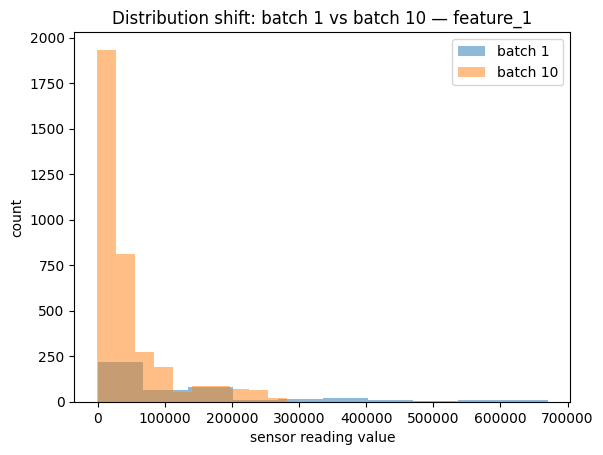

In [4]:
plt.hist(batch_1_feature.to_numpy(), alpha=0.5, label="batch 1")
plt.hist(batch_10_feature.to_numpy(), alpha=0.5, label="batch 10")
plt.legend()
plt.xlabel("sensor reading value")
plt.ylabel("count")
plt.title("Distribution shift: batch 1 vs batch 10 — feature_1")
plt.show()

In [5]:
train_data, _ = split_data(data, split_after_batch=6)
train_X, train_y = train_data.select(pl.exclude("label", "concentration", "batch_id")), train_data.select("label")

In [8]:
clf = RandomForestClassifier()
clf.fit(train_X, train_y)

f1_scores = []

for i in range(1, 11):
    eval_data = data.filter(pl.col("batch_id") == i)
    X, y = eval_data.select(pl.exclude("label", "concentration", "batch_id")), eval_data.select("label")

    y_pred = clf.predict(X)
    score = f1_score(y, y_pred, average="macro")
    f1_scores.append(score)

/Users/miloszglowacki/Desktop/code/python/sensor-drift-compensation/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


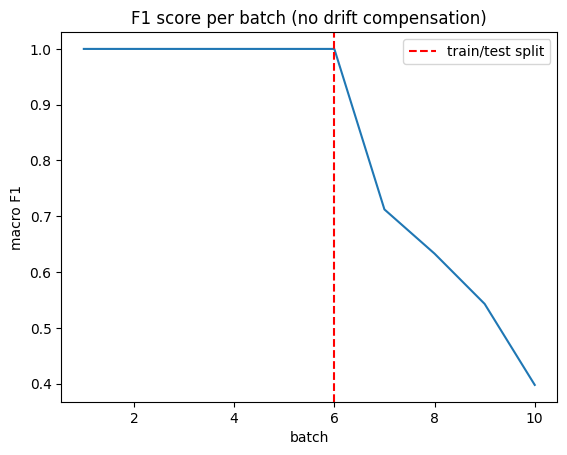

In [15]:
plt.plot(np.arange(1, 11), f1_scores)
plt.axvline(x=6, color="red", linestyle="--", label="train/test split")
plt.xlabel("batch")
plt.ylabel("macro F1")
plt.title("F1 score per batch (no drift compensation)")
plt.legend()
plt.savefig("../results/drift_per_batch.png")
plt.show()